# 16 — AI-factor variants: comparable equity curves & Paleologo tear sheet

Compares **only the variants that use AI factors** — the LLM macro-factor pipeline (regime-loadings prompt → Black-Litterman views → 0.7 HRP-CVaR / 0.3 BL, recall-guarded):

- **Factor PIT** — the deployable point-in-time, recall-guarded line (prompt v1), extended to 2026.
- **Non-PIT (diagnostic)** — the same pipeline with the recall guard *disabled* (identifying framing); NEVER deployable, kept as the memorization control.
- **Factor PIT v2 (rejected)** — the rejected prompt-v2 line (2019–2024 window).

Non-AI comparators (static B&H, Track B, baseline HRP, SPY) are excluded from the gallery on purpose. SPY and the 4-ETF sleeves (SWDA.L, XLK, IAU, BIL) appear only as **regression factors** for the attribution, never as plotted lines.

The tear sheet below reuses the shipped `macro_framework.skill_metric` module (own-basket appraisal ratio + HAC t-stat) and adds **Paleologo two-level attribution**: a single-factor CAPM (vs SPY) and the **own 4-ETF basket** regression that isolates genuine allocation-timing skill from owned factor premia.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import macro_framework as mf
from macro_framework import skill_metric as sk
from macro_framework.ssr import compute_ssr, newey_west_var

pd.set_option("display.width", 220)
TRADING_DAYS = 252
BASKET = ["SWDA.L", "XLK", "IAU", "BIL"]   # own asset-class factors
BENCH = "SPY"                               # market factor

## 1. Load the AI-factor equity lines (trim the pre-2019 lookback burn-in)

In [2]:
DATA = Path.cwd().parent / "data"

# each AI-factor line: (equity parquet, label). ext2026 lines run 2019->2026; v2 runs 2019->2024.
AI_LINES = {
    "Factor PIT":              "factor_equity_ext2026.parquet",
    "Non-PIT (diagnostic)":    "factor_nonpit_diagnostic_equity_ext2026.parquet",
    "Factor PIT v2 (rejected)": "factor_equity_v2.parquet",
}


def active_span(value: pd.Series) -> pd.Series:
    """Trim the leading flat burn-in stub (the HRP-CVaR 756d lookback window before the
    first live rebalance) so performance is measured over the invested span only."""
    moving = value[value.ne(value.iloc[0])]
    if moving.empty:
        return value
    first_move = moving.index.min()
    prior = value.index[value.index < first_move]
    start = prior.max() if len(prior) else first_move
    return value.loc[start:]


equity = {name: active_span(pd.read_parquet(DATA / f)["value"]) for name, f in AI_LINES.items()}
for name, v in equity.items():
    print(f"{name:26s} {v.index[0].date()} .. {v.index[-1].date()}  ({len(v)} days)")

# regression factors (own 4-ETF sleeves + SPY market) from the price DB
prices = mf.get_prices(BASKET + [BENCH], start="2013-01-01", end="2026-07-01")
fac_ret = prices[BASKET].pct_change()
spy_ret = prices[BENCH].pct_change().rename("SPY")
print(f"\nfactors from DB: {prices.index[0].date()} .. {prices.index[-1].date()}  "
      f"(attribution aligns/inner-joins to these dates)")

Factor PIT                 2019-01-02 .. 2026-06-30  (1846 days)
Non-PIT (diagnostic)       2019-01-02 .. 2026-06-30  (1846 days)
Factor PIT v2 (rejected)   2019-01-02 .. 2024-12-30  (1479 days)



factors from DB: 2013-01-02 .. 2026-05-29  (attribution aligns/inner-joins to these dates)


## 2. Comparable equity curves (AI variants only)

All lines rebased to 100 at the first common active date, so the shapes are directly comparable regardless of each line's initial cash.

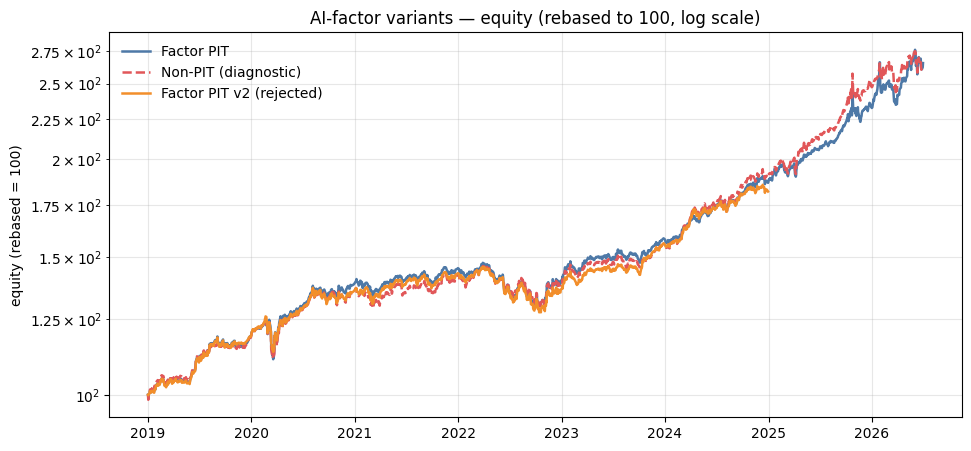

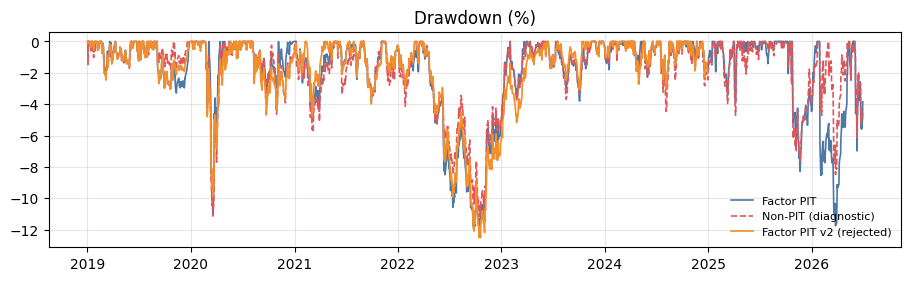

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
common_start = max(v.index[0] for v in equity.values())
colors = {"Factor PIT": "#4e79a7", "Non-PIT (diagnostic)": "#e15759", "Factor PIT v2 (rejected)": "#f28e2b"}
for name, v in equity.items():
    reb = v.loc[common_start:] / v.loc[common_start:].iloc[0] * 100.0
    ax.plot(reb.index, reb.values, label=name, color=colors.get(name), lw=1.8,
            ls="--" if "Non-PIT" in name else "-")
ax.set_yscale("log")
ax.set_title("AI-factor variants — equity (rebased to 100, log scale)")
ax.set_ylabel("equity (rebased = 100)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(frameon=False)

# drawdowns
fig2, ax2 = plt.subplots(figsize=(11, 2.8))
for name, v in equity.items():
    dd = v / v.cummax() - 1.0
    ax2.plot(dd.index, dd.values * 100, label=name, color=colors.get(name), lw=1.2,
             ls="--" if "Non-PIT" in name else "-")
ax2.set_title("Drawdown (%)")
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=False, fontsize=8);

## 3. Tear sheet — standardized metrics + Paleologo attribution

Each AI line scored over its own active window (disclosed in the header note), annualized on the repo's `√252` / calendar-CAGR basis. Reuses `macro_framework.skill_metric` for the own-basket appraisal ratio and its HAC t-stat.

Blocks: **risk/return + tails**, **skill (SSR / Newey-West HAC t)**, **benchmark-relative vs SPY**, and **Paleologo attribution** at two levels — single-factor CAPM (vs SPY) and the **own 4-ETF basket** (the residual that isolates timing skill from owned gold/cash premia). Written to `reports/nb16_ai_variants_tearsheet.csv`.

In [4]:
def _hac_t_mean(r):
    lr, _ = newey_west_var(r.to_numpy())
    return float(r.mean() / np.sqrt(lr / len(r))) if lr > 0 else np.nan


def tear_sheet(equity, fac_ret, spy_ret, ppy=TRADING_DAYS):
    out = {}
    for name, v in equity.items():
        r = v.pct_change().dropna()
        yrs = (v.index[-1] - v.index[0]).days / 365.25
        cagr = (v.iloc[-1] / v.iloc[0]) ** (1 / yrs) - 1
        maxdd = float((v / v.cummax() - 1).min())
        var5 = r.quantile(0.05)
        dsd = np.sqrt((np.minimum(r, 0.0) ** 2).mean())
        ssr = compute_ssr(r)
        b = spy_ret.reindex(r.index); idx = b.dropna().index
        rr, bb = r.reindex(idx), b.reindex(idx)
        active = rr - bb
        te = active.std(ddof=1) * np.sqrt(ppy); ar = active.mean() * ppy
        ma = sk.market_attribution(r, spy_ret, periods_per_year=ppy)          # CAPM headline (beta)
        capm = sk.basket_residual(r, spy_ret.to_frame("SPY"), periods_per_year=ppy)  # CAPM idio/appraisal/HAC-t
        basket = sk.basket_residual(r, fac_ret, periods_per_year=ppy)         # own 4-ETF (timing skill)
        out[name] = {
            "Total Return": float(v.iloc[-1] / v.iloc[0] - 1), "CAGR": float(cagr),
            "Ann. Volatility": float(r.std(ddof=1) * np.sqrt(ppy)),
            "Sharpe": float(r.mean() / r.std(ddof=1) * np.sqrt(ppy)),
            "Downside vol (daily)": float(dsd),
            "Sortino": float(r.mean() / dsd * np.sqrt(ppy)),
            "Max Drawdown": maxdd, "Calmar": float(cagr / abs(maxdd)),
            "VaR 95 (daily)": float(var5), "CVaR 95 (daily)": float(r[r <= var5].mean()),
            "Skew": float(r.skew()), "Excess Kurtosis": float(r.kurtosis()),
            "Hit Rate": float((r > 0).mean()),
            "SSR (Sharpe Stability)": float(ssr.ssr), "HAC t (mean, NW)": _hac_t_mean(r),
            "Correlation to SPY": float(rr.corr(bb)), "Beta (SPY)": float(ma.beta),
            "Active Return (ann.)": float(ar), "Tracking Error (ann.)": float(te),
            "Information Ratio": float(ar / te) if te > 1e-6 else np.nan,
            "CAPM R2 (SPY)": float(capm.r2), "CAPM alpha (ann.)": float(capm.alpha_ann),
            "CAPM idio vol (ann.)": float(capm.idio_vol_ann),
            "CAPM appraisal (a/se)": float(capm.appraisal) if capm.appraisal is not None else np.nan,
            "CAPM t(alpha) HAC": float(capm.t_alpha_hac),
            "Basket R2 (4-ETF)": float(basket.r2), "Basket alpha (ann.)": float(basket.alpha_ann),
            "Basket idio vol (ann.)": float(basket.idio_vol_ann),
            "Basket appraisal (a/se)": float(basket.appraisal) if basket.appraisal is not None else np.nan,
            "Basket t(alpha) HAC": float(basket.t_alpha_hac),
        }
    return pd.DataFrame(out)


_PCT = {"Total Return", "CAGR", "Ann. Volatility", "Downside vol (daily)", "Max Drawdown",
        "VaR 95 (daily)", "CVaR 95 (daily)", "Hit Rate", "Active Return (ann.)",
        "Tracking Error (ann.)", "CAPM alpha (ann.)", "CAPM idio vol (ann.)",
        "Basket alpha (ann.)", "Basket idio vol (ann.)"}


def fmt(sheet):
    return pd.DataFrame({c: [f"{sheet.loc[m, c]*100:.1f}%" if m in _PCT else f"{sheet.loc[m, c]:.2f}"
                            for m in sheet.index] for c in sheet.columns}, index=sheet.index)


sheet = tear_sheet(equity, fac_ret, spy_ret)
reports = Path.cwd().parent / "reports"
reports.mkdir(exist_ok=True)
sheet.to_csv(reports / "nb16_ai_variants_tearsheet.csv", float_format="%.6f")
print("windows:", {n: (v.index[0].date().isoformat(), v.index[-1].date().isoformat()) for n, v in equity.items()})
print(f"wrote {reports / 'nb16_ai_variants_tearsheet.csv'}\n")
display(fmt(sheet))

windows: {'Factor PIT': ('2019-01-02', '2026-06-30'), 'Non-PIT (diagnostic)': ('2019-01-02', '2026-06-30'), 'Factor PIT v2 (rejected)': ('2019-01-02', '2024-12-30')}
wrote /home/mc/projects/Global_Macro_AI_Factors/reports/nb16_ai_variants_tearsheet.csv



,Factor PIT,Non-PIT (diagnostic),Factor PIT v2 (rejected)
Total Return,165.5%,163.2%,81.9%
CAGR,13.9%,13.8%,10.5%
Ann. Volatility,9.7%,9.8%,7.8%
Sharpe,1.43,1.40,1.35
Downside vol (daily),0.4%,0.4%,0.3%
Sortino,2.07,2.06,1.98
Max Drawdown,-12.1%,-11.2%,-12.5%
Calmar,1.15,1.23,0.84
VaR 95 (daily),-0.8%,-0.9%,-0.8%
CVaR 95 (daily),-1.4%,-1.4%,-1.1%


## 4. Reading the sheet

- **PIT vs Non-PIT** is the memorization control: near-identical risk/return means the recall guard removes look-ahead without costing performance — the AI view adds ~nothing that survives PIT.
- **Skill is the story the Paleologo block tells.** A large single-factor CAPM `alpha` at low `beta` looks like skill, but the **own 4-ETF basket** regression (R² ≈ 0.8+) shows most of it is static factor exposure: the **basket appraisal** and its **HAC t-stat** are the honest timing-skill numbers. A basket `t(alpha)` below ~2 means the residual (allocation-timing) alpha is **not statistically distinguishable from zero** — the edge is factor premia + low market beta, not AI timing skill.
- **SSR far below 1.96** independently flags the Sharpe as luck-compatible.

Prices for the attribution factors come from the `etf_prices` DB (raw close); the equity lines were built on adjusted prices, so treat the attribution betas/R² as close but not to-the-basis-point.